### EXPLICATION DE LA LOGIQUE 
``
Cette étude permettra d'évaluer le thermomètre de la santé alimentaire mondiale
Les indices FAO des prix alimentaires sont des baromètres mondiaux qui mesurent les variations mensuelles des prix internationaux des principales denrées alimentaires.
Quand l'indice monte au dessu de la base (dans notre dataset la base c'est 100 sur les années 2014 à 2016) -> Les aliments coûtent plus cher dans le monde
Quand l'indice baisse de 20% par exemple-> Les aliments sont moins chers donc sont 20% moins cher que l'année de reférence

* Nous avons 06 indices y compris les produits eux mêmes :
* FIP (Food Price Index) ----> Prix alimentaires GLOBAUX / Moyenne pondérée des cinq autres indices.
  Le FIP représente l'indice global et agrégé de l'évolution des prix alimentaires mondiaux. C'est la mesure de haut niveau qui résume l'ensemble de la situation.
* Cereals	                Céréales Blé, maïs, riz
* Oils	                    Huiles végétales	Huile de palme, soja, colza
* Meat	                    Viandes	Bœuf, porc, volaille
* Dairy	                    Produits laitiers	Lait, beurre, fromage
* Sugar	                    Sucre	Sucre brut et raffiné



### ANALYSE 

[1] CHARGEMENT DES DONNÉES
Objectif : Vérifier que les données sont complètes et correctes (Nettoyage des données)

Ce qu'on regarde :

Nombre de lignes (mois couverts)
Période : 1990 -> 2024 (34 ans)
Colonnes présentes : Date + 6 indices
Pertinence :  Confirme qu'on a des données sur le long terme ---- Permet de détecter problèmes dès le début


[2]QUALITÉ DES DONNÉES 
Objectif : S'assurer que les données sont fiables

Ce qu'on vérifie :

-> Valeurs manquantes : 0 = Excellent
-> Outliers (valeurs aberrantes) détectés par méthode IQR
Méthode IQR (Interquartile Range) :

Calcule Q1 (25e percentile) et Q3 (75e percentile)
IQR = Q3 - Q1
Outliers = valeurs < Q1 - 1.5×IQR OU > Q3 + 1.5×IQR
Pertinence :  Évite d'analyser des données erronées  Identifie les pics anormaux (guerres, crises)


[3] ÉVOLUTION TEMPORELLE GLOBALE 
Objectif : Voir comment les prix ont évolué depuis 1990

Image 1 (votre capture) montre :

Graphique du haut : Tous les indices ensemble

 Ce qu'on voit :
- Tendance générale HAUSSIÈRE (tous les indices montent)
- Pic MAJEUR en 2008 (crise alimentaire mondiale)
- Pic en 2011-2012 (sécheresse, spéculation)
- Hausse récente 2020-2024 (COVID + guerre Ukraine)
Graphique du bas : FIP avec moyenne mobile

 Moyenne mobile (ligne rouge) = tendance LISSÉE
- Supprime les fluctuations mensuelles
- Montre la tendance de fond
- Fenêtre 12 mois = tendance annuelle
Pertinence pour votre projet :  Contextualise les prix locaux : Si riz cher au Sénégal en 2008 → normal car crise mondiale  Identifie périodes critiques : 2008, 2011, 2020-2024 = périodes de stress  Baseline mondiale : Comparer évolution locale vs mondiale





In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [60]:
df = pd.read_csv("food_price_indices_data_csv_dec.csv")
df.head(10)

,FAO Food Price Index,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 56,Unnamed: 57,Unnamed: 58,Unnamed: 59,Unnamed: 60,Unnamed: 61,Unnamed: 62,Unnamed: 63,Unnamed: 64,Unnamed: 65
0,2014-2016=100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Date,Food Price Index,Meat,Dairy,Cereals,Oils,Sugar,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1990-01,64.4,74.3,53.5,64.1,44.59,87.9,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1990-02,64.7,76.8,52.2,62.2,44.50,90.7,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,1990-03,64.0,78.5,41.4,61.3,45.75,95.1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,1990-04,66.0,81.2,48.4,62.8,44.02,94.3,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,1990-05,64.6,81.8,39.2,62.0,45.50,90.4,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,1990-06,64.1,84.2,39.2,60.7,43.80,80.3,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,1990-07,62.9,84.5,39.2,57.9,43.72,74.2,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df.shape

(434, 66)

In [11]:
dff= df.iloc[3:, :7]

In [12]:
dff.head(5)

,FAO Food Price Index,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6
3,1990-01,64.4,74.3,53.5,64.1,44.59,87.9
4,1990-02,64.7,76.8,52.2,62.2,44.50,90.7
5,1990-03,64.0,78.5,41.4,61.3,45.75,95.1
6,1990-04,66.0,81.2,48.4,62.8,44.02,94.3
7,1990-05,64.6,81.8,39.2,62.0,45.50,90.4


In [61]:
# rename columns 

new_columns=['Date',	'FIP',	'Meat',	'Dairy',	'Cereals',	'Oils',	'Sugar']
dff.columns = new_columns
dff

,Date,FIP,Meat,Dairy,Cereals,Oils,Sugar
3,1990-01,64.4,74.3,53.5,64.1,44.59,87.9
4,1990-02,64.7,76.8,52.2,62.2,44.50,90.7
5,1990-03,64.0,78.5,41.4,61.3,45.75,95.1
6,1990-04,66.0,81.2,48.4,62.8,44.02,94.3
7,1990-05,64.6,81.8,39.2,62.0,45.50,90.4
...,...,...,...,...,...,...,...
429,2025-07,129.8,126.7,154.6,106.5,166.8,103.3
430,2025-08,130.0,127.8,152.3,105.7,169.1,103.6
431,2025-09,128.7,128.1,147.2,104.9,167.9,99.4
432,2025-10,126.6,125.5,141.9,103.6,169.4,94.1


In [62]:
dff1 = dff.reset_index()

In [63]:
dff1

,index,Date,FIP,Meat,Dairy,Cereals,Oils,Sugar
0,3,1990-01,64.4,74.3,53.5,64.1,44.59,87.9
1,4,1990-02,64.7,76.8,52.2,62.2,44.50,90.7
2,5,1990-03,64.0,78.5,41.4,61.3,45.75,95.1
3,6,1990-04,66.0,81.2,48.4,62.8,44.02,94.3
4,7,1990-05,64.6,81.8,39.2,62.0,45.50,90.4
...,...,...,...,...,...,...,...,...
426,429,2025-07,129.8,126.7,154.6,106.5,166.8,103.3
427,430,2025-08,130.0,127.8,152.3,105.7,169.1,103.6
428,431,2025-09,128.7,128.1,147.2,104.9,167.9,99.4
429,432,2025-10,126.6,125.5,141.9,103.6,169.4,94.1


In [64]:
dff1.describe()

,index
count,431.000000
mean,218.000000
std,124.563237
min,3.000000
25%,110.500000
50%,218.000000
75%,325.500000
max,433.000000


In [65]:
dff1 = dff1.drop_duplicates()
print(f"Nombre de lignes après suppression des doublons: {len(dff1)}")
print(f"Doublons supprimés: {len(dff1) - len(dff1.drop_duplicates())}")


Nombre de lignes après suppression des doublons: 431
Doublons supprimés: 0


In [23]:
dff1.shape
dff1.head(5)

,index,Date,FIP,Meat,Dairy,Cereals,Oils,Sugar
0,3,1990-01,64.4,74.3,53.5,64.1,44.59,87.9
1,4,1990-02,64.7,76.8,52.2,62.2,44.50,90.7
2,5,1990-03,64.0,78.5,41.4,61.3,45.75,95.1
3,6,1990-04,66.0,81.2,48.4,62.8,44.02,94.3
4,7,1990-05,64.6,81.8,39.2,62.0,45.50,90.4


In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

In [67]:

# Configuration des graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (16, 6)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print("EDA - FAO FOOD PRICE INDEX")


EDA - FAO FOOD PRICE INDEX


In [68]:
# Convertir la date
dff1['Date'] = pd.to_datetime(dff1['Date'])

# Trier par date
dff1 = dff1.sort_values('Date').reset_index(drop=True)

In [69]:
print(f" Données chargées: {dff1.shape}")
print(f"  Période: {dff1['Date'].min().strftime('%Y-%m')} à {dff1['Date'].max().strftime('%Y-%m')}")
print(f"  Durée: {(dff1['Date'].max() - dff1['Date'].min()).days / 365.25:.1f} années")
print(f"  Fréquence: {len(dff1)} observations")


 Données chargées: (431, 8)
  Période: 1990-01 à 2025-11
  Durée: 35.8 années
  Fréquence: 431 observations


In [70]:
print("\n Aperçu des données:")
print(dff1.head(10))


 Aperçu des données:
   index       Date   FIP  Meat Dairy Cereals   Oils Sugar
0      3 1990-01-01  64.4  74.3  53.5    64.1  44.59  87.9
1      4 1990-02-01  64.7  76.8  52.2    62.2  44.50  90.7
2      5 1990-03-01  64.0  78.5  41.4    61.3  45.75  95.1
3      6 1990-04-01  66.0  81.2  48.4    62.8  44.02  94.3
4      7 1990-05-01  64.6  81.8  39.2    62.0  45.50  90.4
5      8 1990-06-01  64.1  84.2  39.2    60.7  43.80  80.3
6      9 1990-07-01  62.9  84.5  39.2    57.9  43.72  74.2
7     10 1990-08-01  61.8  84.5  36.8    55.7  45.37  67.6
8     11 1990-09-01  61.3  85.5  38.1    52.5  44.79  68.5
9     12 1990-10-01  61.4  86.2  38.9    52.8  45.72  60.8


In [71]:
print("\n Informations sur les colonnes:")
print(dff1.info())


 Informations sur les colonnes:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 431 entries, 0 to 430
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   index    431 non-null    int64         
 1   Date     431 non-null    datetime64[ns]
 2   FIP      431 non-null    object        
 3   Meat     431 non-null    object        
 4   Dairy    431 non-null    object        
 5   Cereals  431 non-null    object        
 6   Oils     431 non-null    object        
 7   Sugar    431 non-null    object        
dtypes: datetime64[ns](1), int64(1), object(6)
memory usage: 27.1+ KB
None


In [72]:
print("\n Statistiques descriptives:")
print(dff1.describe().round(2))


 Statistiques descriptives:
        index                           Date
count  431.00                            431
mean   218.00  2007-12-01 05:44:07.795823616
min      3.00            1990-01-01 00:00:00
25%    110.50            1998-12-16 12:00:00
50%    218.00            2007-12-01 00:00:00
75%    325.50            2016-11-16 00:00:00
max    433.00            2025-11-01 00:00:00
std    124.56                            NaN


## 2. QUALITÉ DES DONNÉES

[2] QUALITÉ DES DONNÉES 
Objectif : S'assurer que les données sont fiables

Ce qu'on vérifie :

-> Valeurs manquantes : 0 = Excellent
-> Outliers (valeurs aberrantes) détectés par méthode IQR
Méthode IQR (Interquartile Range) :

Calcule Q1 (25e percentile) et Q3 (75e percentile)
IQR = Q3 - Q1
Outliers = valeurs < Q1 - 1.5 × IQR 
OU valeurs > Q3 + 1.5 × IQR
Pertinence :  Évite d'analyser des données erronées  Identifie les pics anormaux (guerres, crises)


In [73]:
# 2. QUALITÉ DES DONNÉES

print("\n\n[2] QUALITÉ DES DONNÉES")


# Valeurs manquantes
missing = dff1.isnull().sum()
missing_pct = (missing / len(dff1) * 100).round(2)

#Parcourir les colonnes à la recherche de valeurs manquantes
print("\n Valeurs manquantes:")
for col in dff1.columns:
    if missing[col] > 0:
        print(f"  {col:15s}: {missing[col]:4d} ({missing_pct[col]:5.1f}%)")
    else:
        print(f"  {col:15s}:  Aucune")

# Valeurs aberrantes potentielles
# FIP (Food Price Index)	
print("\n  Détection des valeurs aberrantes (méthode IQR):\n")

indices_cols = ['FIP', 'Meat', 'Dairy', 'Cereals', 'Oils', 'Sugar']

# Convertir les colonnes en numérique AVANT de lancer la détection d'outliers
for col in indices_cols:
    dff1[col] = pd.to_numeric(dff1[col], errors='coerce')

outliers_summary = []
for col in indices_cols:
    Q1 = dff1[col].quantile(0.25)
    Q3 = dff1[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = dff1[(dff1[col] < lower_bound) | (dff1[col] > upper_bound)]
    outliers_summary.append({
        'Indice': col,
        'Outliers': len(outliers),
        'Min': dff1[col].min(),
        'Max': dff1[col].max(),
        'Seuil_bas': lower_bound,
        'Seuil_haut': upper_bound
    })

outliers_df = pd.DataFrame(outliers_summary)
print(outliers_df.to_string(index=False))




[2] QUALITÉ DES DONNÉES

 Valeurs manquantes:
  index          :  Aucune
  Date           :  Aucune
  FIP            :  Aucune
  Meat           :  Aucune
  Dairy          :  Aucune
  Cereals        :  Aucune
  Oils           :  Aucune
  Sugar          :  Aucune

  Détection des valeurs aberrantes (méthode IQR):

 Indice  Outliers   Min   Max  Seuil_bas  Seuil_haut
    FIP         0 50.80 160.2    -12.900     193.900
   Meat         0 52.30 128.1     31.625     143.025
  Dairy         0 36.80 158.2    -32.050     206.750
Cereals         0 48.60 173.5    -16.050     188.350
   Oils         4 35.83 251.8    -20.990     205.370
  Sugar         2 31.80 183.2    -12.350     180.850


[2]QUALITÉ DES DONNÉES 
Objectif : S'assurer que les données sont fiables

Ce qu'on vérifie :

-> Valeurs manquantes : 0 = Excellent
-> Outliers (valeurs aberrantes) détectés par méthode IQR
Méthode IQR (Interquartile Range) :

Calcule Q1 (25e percentile) et Q3 (75e percentile)
IQR = Q3 - Q1
Outliers = valeurs < Q1 - 1.5×IQR 
OU valeurs > Q3 + 1.5×IQR
Pertinence :  Évite d'analyser des données erronées  
Identifie les pics anormaux (guerres, crises)


## 3. ANALYSE TEMPORELLE GLOBALE

[3] ÉVOLUTION TEMPORELLE GLOBALE 
Objectif : Voir comment les prix ont évolué depuis 2002

Graphique du haut : Tous les indices ensemble

 Ce qu'on voit :
- Tendance générale HAUSSIÈRE (tous les indices montent)
- Pic MAJEUR en 2008 (crise alimentaire mondiale)
- Pic en 2011-2012 (sécheresse, spéculation)
- Hausse récente 2020-2024 (COVID + guerre Ukraine)
  
Graphique du bas : FIP avec moyenne mobile

 Moyenne mobile (ligne rouge) = tendance LISSÉE
- Supprime les fluctuations mensuelles
- Montre la tendance de fond
- Fenêtre 12 mois = tendance annuelle
Pertinence :  Contextualise les prix locaux : Si le riz est cher par exemple au Sénégal en 2008 -> normal car crise mondiale
Identifie les périodes critiques : 2008, 2011, 2020-2024 = périodes de stress
Baseline mondiale : Comparer évolution locale vs mondiale





[3] ANALYSE TEMPORELLE GLOBALE

 Statistiques par décennie:
        Observations  Moyenne  Médiane  Écart-type   Min    Max
Decade                                                         
2000              96    77.75    69.80       21.88  50.8  132.7
2010             120   107.01    99.25       14.62  84.9  137.7
2020              24   111.90   111.00       15.41  91.2  135.4


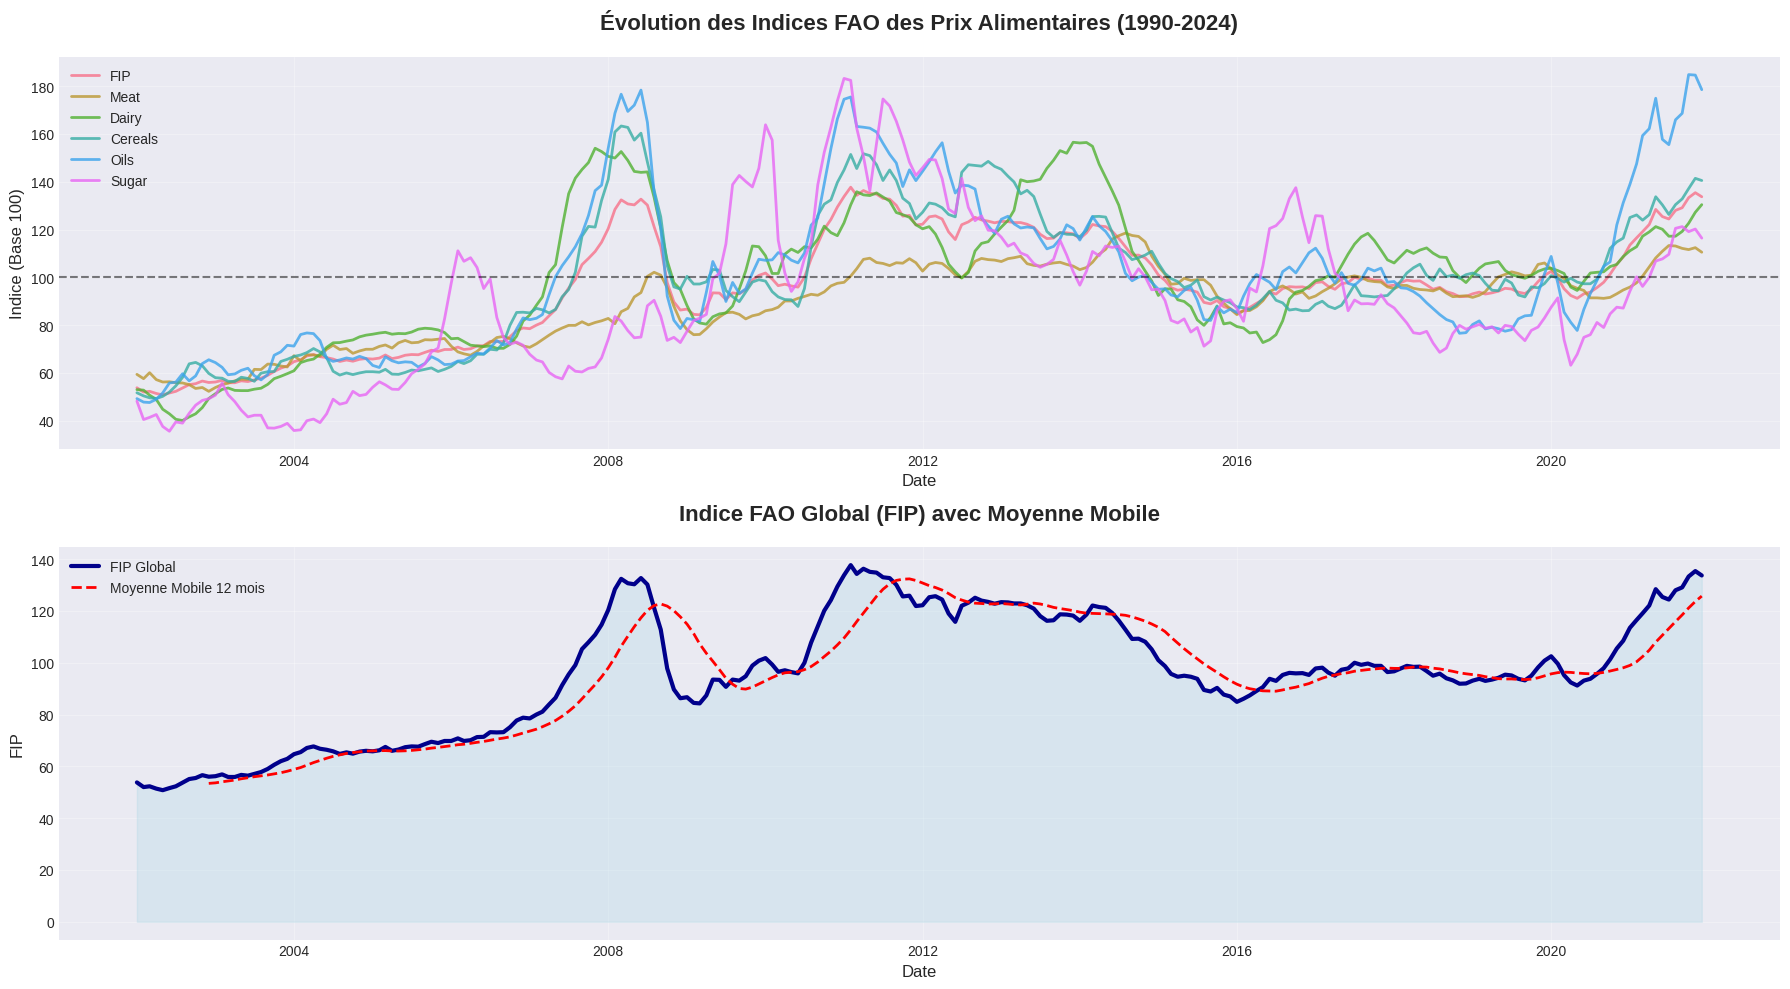

In [ ]:
# 3. ANALYSE TEMPORELLE GLOBALE


print("\n\n[3] ANALYSE TEMPORELLE GLOBALE")


# Créer des variables temporelles
dff1['Year'] = dff1['Date'].dt.year
dff1['Month'] = dff1['Date'].dt.month
dff1['Quarter'] = dff1['Date'].dt.quarter

# Statistiques par décennie
dff1['Decade'] = (dff1['Year'] // 10) * 10

print("\n Statistiques par décennie:")
decade_stats = dff1.groupby('Decade')['FIP'].agg([
    ('Observations', 'count'),
    ('Moyenne', 'mean'),
    ('Médiane', 'median'),
    ('Écart-type', 'std'),
    ('Min', 'min'),
    ('Max', 'max')
]).round(2)
print(decade_stats)

# filtration des dates 
dff1_filtre = dff1.loc[(dff1['Year'] >= 2002) & (dff1['Year'] <= 2021)]

# Visualisation de l'évolution globale
fig, axes = plt.subplots(2, 1, figsize=(18, 10))

# Graphique 1: Évolution de tous les indices
ax1 = axes[0]
for col in indices_cols:
    ax1.plot(dff1_filtre['Date'], dff1_filtre[col], label=col, linewidth=2, alpha=0.8)

ax1.set_title('Évolution des Indices FAO des Prix Alimentaires (1990-2024)', 
             fontsize=16, fontweight='bold', pad=20)
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Indice (Base 100)', fontsize=12)
ax1.legend(loc='upper left', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.axhline(100, color='black', linestyle='--', alpha=0.5, label='Base 100')

# Graphique 2: Focus sur FIP (Food Price Index global)
ax2 = axes[1]
ax2.plot(dff1_filtre['Date'], dff1_filtre['FIP'], linewidth=3, color='darkblue', label='FIP Global')
ax2.fill_between(dff1_filtre['Date'], dff1_filtre['FIP'], alpha=0.3, color='lightblue')

# Ajouter moyenne mobile
dff1_filtre['FIP_MA12'] = dff1_filtre['FIP'].rolling(window=12).mean()
ax2.plot(dff1_filtre['Date'], dff1_filtre['FIP_MA12'], linewidth=2, color='red', 
        linestyle='--', label='Moyenne Mobile 12 mois')

ax2.set_title('Indice FAO Global (FIP) avec Moyenne Mobile', 
             fontsize=16, fontweight='bold', pad=20)
ax2.set_xlabel('Date', fontsize=12)
ax2.set_ylabel('FIP', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


[3] ÉVOLUTION TEMPORELLE GLOBALE 
Objectif : Voir comment les prix ont évolué depuis 1990

#### Graphique du haut : Tous les indices ensemble
```
 Ce qu'on voit :
- Tendance générale HAUSSIÈRE (tous les indices montent)
- Pic MAJEUR en 2008 (crise alimentaire mondiale)
- Pic en 2011-2012 (sécheresse, spéculation)
- Hausse récente 2020-2024 (COVID + guerre Ukraine)
```

#### Graphique du bas : FIP avec moyenne mobile
```
 Moyenne mobile = tendance LISSÉE
- Supprime les fluctuations mensuelles
- Montre la tendance de fond
- Fenêtre 12 mois = tendance annuelle
Cela permet de contextualiser les prix locaux : Si riz cher au Sénégal en 2008 -> normal car crise mondiale
Identifie périodes critiques : 2008, 2011, 2020-2024 = périodes de stress
* Hausse du prix du pétrole : En mai 2008, le baril frôlait 130 $, impactant les coûts de production agricole (engrais, carburant) et de transport des denrées.
Baseline mondiale : Comparer évolution locale vs mondiale



[4] ANALYSE PAR CATÉGORIE 
#### Objectif : Comparer les différents types de denrées, Obtenir les statistiques par catégorie
#### Question centrale : "Comment les prix se comportent-ils pour chaque type de denrée ?"

*  Quelle est la valeur de chaque indice ?
*  Est-ce que les prix sont stables ou changeants ?
*  Quels produits ont les plus grandes variations ?
*  


Exemple (FIP) :
- Moyenne : 95.88; moyenne des prix au niveau de l'indice FIP
 En **moyenne**, l'indice global des prix alimentaires est autour de 96
- Base 100 = années 2002-2004
- 95.88 ≈ 100 -> Les prix sont proches de la référence

- Écart-type : 23.23 -> Mesure de volatilité, Indique **à quel point les valeurs s'éloignent** de la moyenne
- Min : 58.86 (1990)
- Max : 137.7 (2022)
- CV% : 24.25% -> Coefficient de variation
Formule CV : (Écart-type / Moyenne) × 100

Interprétation CV% (Classement Volatilité)
CV%	Signification
< 15%	Stable (peu de variations)
15-25%	Modéré (variations moyennes)
> 25%	Très volatile (fluctuations fortes)

Classement volatilité (Image 2) :

Sugar : 36.84% -> LE PLUS VOLATILE
Oils : 32.46%
Cereals : 28.63%
Dairy : 28.01%
FIP : 24.25%
Meat : 18.55% -> LE PLUS STABLE

Les 6 histogrammes 
FIP : Distribution bimodale (2 pics) -> 2 régimes de prix
Meat : Distribution normale -> Prix stables
Dairy : Légèrement asymétrique
Cereals : Large dispersion -> Grande variabilité
Oils : Distribution étalée -> Très volatile
Sugar : Très étalé avec pic récent
Pertinence :  Identifie produits à risque : Sugar et Oils = surveiller en priorité 
Priorise interventions : Stabiliser les plus volatiles d'abord 
Comprend nature des marchés : Pourquoi certains sont plus instables




[4] ANALYSE PAR CATÉGORIE

 Statistiques par catégorie:
           mean    std    min    max  CV(%)
FIP       95.80  23.23  50.80  137.7  24.25
Meat      88.99  16.51  52.30  118.5  18.55
Dairy    100.03  28.02  40.10  156.5  28.01
Cereals   99.27  28.42  49.30  163.3  28.63
Oils     101.93  33.09  47.62  184.8  32.46
Sugar     90.83  33.46  35.60  183.2  36.84

 Classement par volatilité (CV%):
  1. Sugar     :  36.84%
  2. Oils      :  32.46%
  3. Cereals   :  28.63%
  4. Dairy     :  28.01%
  5. FIP       :  24.25%
  6. Meat      :  18.55%


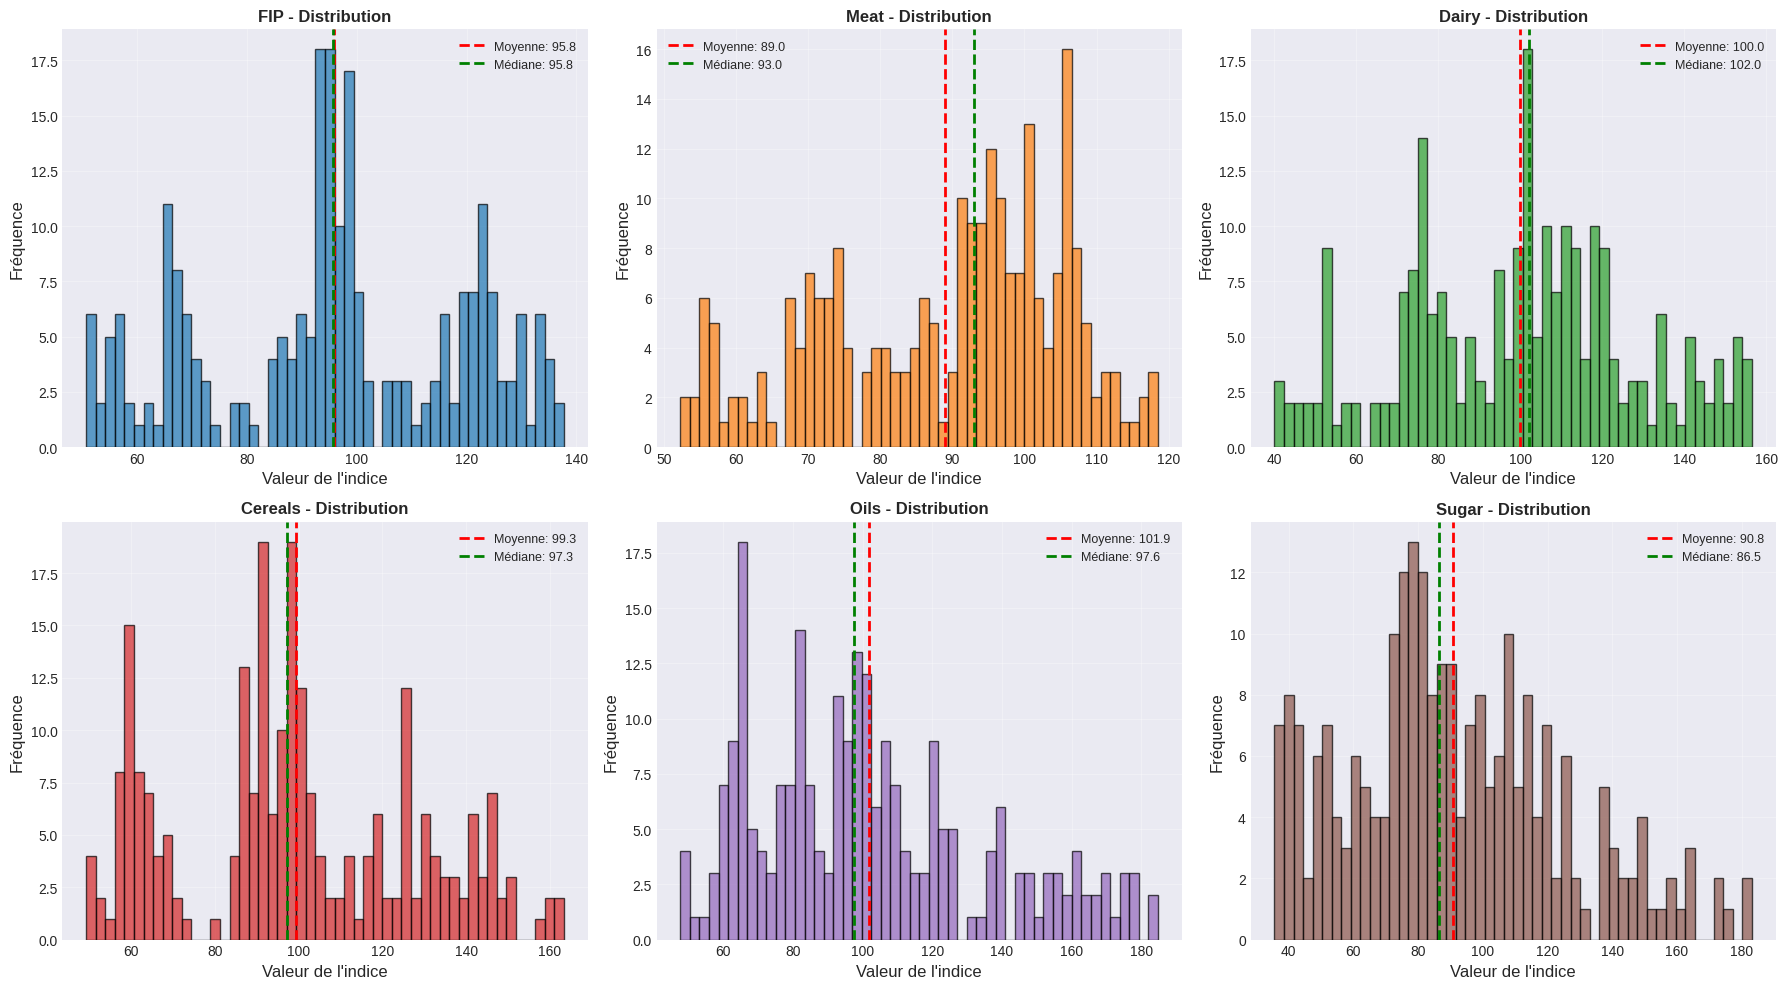

In [ ]:
# 4. ANALYSE PAR CATÉGORIE

print("\n\n[4] ANALYSE PAR CATÉGORIE")

# Statistiques comparatives
category_stats = dff1[indices_cols].describe().T
category_stats['CV(%)'] = (category_stats['std'] / category_stats['mean'] * 100).round(2)
category_stats = category_stats.round(2)

print("\n Statistiques par catégorie:")
print(category_stats[['mean', 'std', 'min', 'max', 'CV(%)']].to_string())

# Identifier les catégories les plus volatiles
print("\n Classement par volatilité (CV%):")
volatility_rank = category_stats['CV(%)'].sort_values(ascending=False)
for idx, (cat, vol) in enumerate(volatility_rank.items(), 1):
    print(f"  {idx}. {cat:10s}: {vol:6.2f}%")

# Visualisation: Distribution des indices
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

for idx, (col, color) in enumerate(zip(indices_cols, colors)):
    ax = axes[idx]
    
    # Histogramme
    ax.hist(dff1[col].dropna(), bins=50, color=color, alpha=0.7, edgecolor='black')
    
    # Statistiques
    mean_val = dff1[col].mean()
    median_val = dff1[col].median()
    
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Moyenne: {mean_val:.1f}')
    ax.axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Médiane: {median_val:.1f}')
    
    ax.set_title(f'{col} - Distribution', fontsize=12, fontweight='bold')
    ax.set_xlabel('Valeur de l\'indice')
    ax.set_ylabel('Fréquence')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

[4] ANALYSE PAR CATÉGORIE 
#### Objectif : Comparer les différents types de denrées, Obtenir les statistiques par catégorie
#### Question centrale : "Comment les prix se comportent-ils pour chaque type de denrée ?"

*  Quelle est la valeur de chaque indice ?
*  Est-ce que les prix sont stables ou changeants ?
*  Quels produits ont les plus grandes variations ?
*  


Exemple (FIP) :
- Moyenne : 95.88 moyenne des prix au niveau de l'indice FIP
 En **moyenne**, l'indice global des prix alimentaires est autour de 96
- Base 100 = années 2002-2004
- 95.88 ≈ 100 -> Les prix sont proches de la référence

- Écart-type : 23.23 -> Mesure de volatilité, Indique **à quel point les valeurs s'éloignent** de la moyenne
- Min : 50.80 (1990)
- Max : 137.7 (2022)
- CV% : 24.25% -> Coefficient de variation
Formule CV : (Écart-type / Moyenne) × 100

Interprétation CV%
CV%	Signification
< 15%	Stable (peu de variations)
15-25%	Modéré (variations moyennes)
> 25%	Très volatile (fluctuations fortes)

Classement volatilité : (peut permettre de savoir sur quoi investir ou non)

Sugar : 36.84% -> LE PLUS VOLATILE
Oils : 32.46%
Cereals : 28.63%
Dairy : 28.01%
FIP : 24.25%
Meat : 18.55% -> LE PLUS STABLE

> Les 6 histogrammes :

* La Valeur indice: représente le nombre de fois où la valeur apparait sur le temps (nbr de mois)
FIP : Distribution bimodale (2 pics) -> 2 régimes de prix
Meat : Distribution normale -> Prix stables
Dairy : Légèrement asymétrique
Cereals : Large dispersion -> Grande variabilité
Oils : Distribution étalée -> Très volatile
Sugar : Très étalé avec pic récent

Pertinence :  Identifie produits à risque : Sugar et Oils = surveiller en priorité 
Priorise interventions : Stabiliser les plus volatiles d'abord 
Comprend nature des marchés : Pourquoi certains sont plus instables


## 5. ANALYSE DES TENDANCES

[5] ANALYSE DES TENDANCES 
Objectif : Mesurer la hausse/baisse sur le long terme


Graphique du haut : Données réelles brutes

Toutes les fluctuations visibles
Montre la volatilité réelle

Graphique du bas : Lignes de tendance linéaire
Chaque indice a sa droite de régression
Pente positive = hausse long terme
Pente négative = baisse long terme
Calcul de tendance :

Cereals :
- Valeur 2002 : ~ 64
- Valeur 2024 : ~105.5
- Variation : +64% en 22 ans
- Tendance : +3% par an en moyenne
Pertinence :  Projection long terme : Prévoir évolution future 
Comparaison produits : Lesquels montent le plus vite 
Planification budgétaire : Anticiper coûts futurs



 Tendances à long terme:
 Indice  Pente  Tendance (%)   R²  Valeur_2002  Valeur_2024  Variation_réelle (%)
    FIP   0.17        143.91 0.63        64.40        125.1                 94.25
   Meat   0.11         74.76 0.56        74.30        124.6                 67.70
  Dairy   0.23        256.24 0.68        53.50        137.5                157.01
Cereals   0.19        161.77 0.54        64.10        105.5                 64.59
   Oils   0.23        231.46 0.53        44.59        165.0                270.04
  Sugar   0.16        133.47 0.36        87.90         88.6                  0.80




[5] ANALYSE DES TENDANCES

 Tendances à long terme:
 Indice  Pente  Tendance (%)   R²  Valeur_2002  Valeur_2024  Variation_réelle (%)
    FIP   0.17        143.91 0.63        64.40        125.1                 94.25
   Meat   0.11         74.76 0.56        74.30        124.6                 67.70
  Dairy   0.23        256.24 0.68        53.50        137.5                157.01
Cereals   0.19        161.77 0.54        64.10        105.5                 64.59
   Oils   0.23        231.46 0.53        44.59        165.0                270.04
  Sugar   0.16        133.47 0.36        87.90         88.6                  0.80


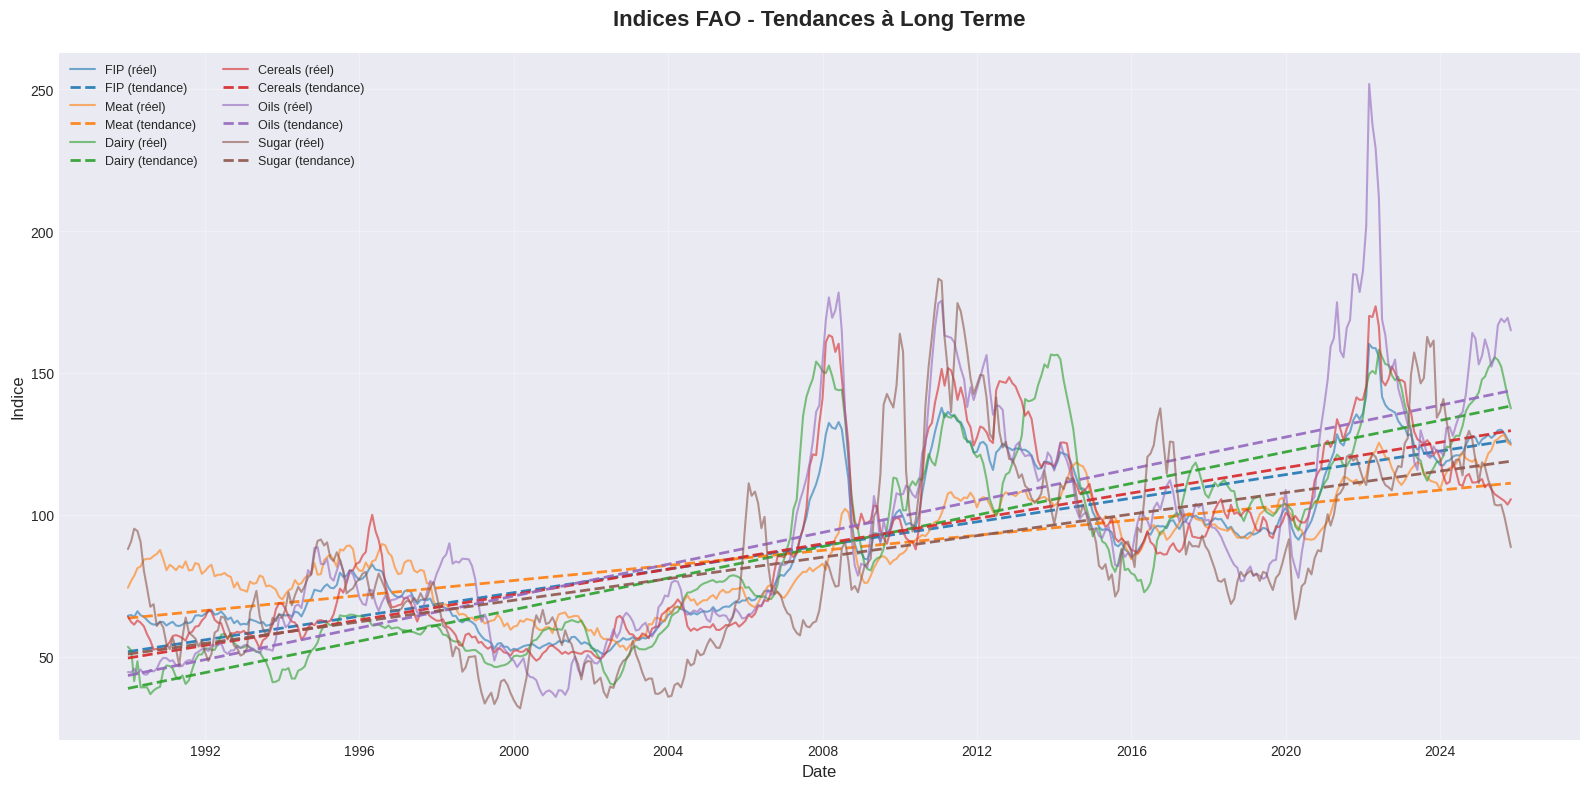

In [ ]:
# 5. ANALYSE DES TENDANCES

print("\n\n[5] ANALYSE DES TENDANCES")

# Calculer les tendances (régression linéaire)
from sklearn.linear_model import LinearRegression

trends = []
for col in indices_cols:
    X = np.arange(len(dff1)).reshape(-1, 1)
    y = dff1[col].values
    
    model = LinearRegression()
    model.fit(X, y)
    
    # Prédictions
    y_pred = model.predict(X)
    
    # Calcul de la tendance en %
    initial_value = y_pred[0]
    final_value = y_pred[-1]
    trend_pct = ((final_value - initial_value) / initial_value) * 100
    
    # R²
    from sklearn.metrics import r2_score
    r2 = r2_score(y, y_pred)
    
    trends.append({
        'Indice': col,
        'Pente': model.coef_[0],
        'Tendance (%)': trend_pct,
        'R²': r2,
        'Valeur_2002': y[0],
        'Valeur_2024': y[-1],
        'Variation_réelle (%)': ((y[-1] - y[0]) / y[0]) * 100
    })

trends_df = pd.DataFrame(trends)
trends_df = trends_df.round(2)

print("\n Tendances à long terme:")
print(trends_df.to_string(index=False))

# Visualisation des tendances
fig, ax = plt.subplots(figsize=(16, 8))

colors_trend = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

for idx, col in enumerate(indices_cols):
    X = np.arange(len(dff1)).reshape(-1, 1)
    y = dff1[col].values
    
    model = LinearRegression()
    model.fit(X, y)
    y_trend = model.predict(X)
    
    # Données réelles
    ax.plot(dff1['Date'], y, label=f'{col} (réel)', linewidth=1.5, 
           alpha=0.6, color=colors_trend[idx])
    
    # Ligne de tendance
    ax.plot(dff1 ['Date'], y_trend, linestyle='--', linewidth=2, 
           label=f'{col} (tendance)', color=colors_trend[idx], alpha=0.9)

ax.set_title('Indices FAO - Tendances à Long Terme', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Indice', fontsize=12)
ax.legend(loc='upper left', fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


#### Visualisation des tendances sur 2 graphiques séparés

[5] ANALYSE DES TENDANCES 
Objectif : Mesurer la hausse/baisse sur le long terme


Graphique du haut : Données réelles brutes

Toutes les fluctuations visibles
Montre la volatilité réelle
Graphique du bas : Lignes de tendance linéaire
Chaque indice a sa droite de régression
Pente positive = hausse long terme
Pente négative = baisse long terme
Calcul de tendance :

Cereals :
- Valeur 2002 : ~ 64
- Valeur 2024 : ~120
- Variation : +64% en 22 ans
- Tendance : +3% par an en moyenne
Pertinence :  Projection long terme : Prévoir évolution future 
Comparaison produits : Lesquels montent le plus vite 
Planification budgétaire : Anticiper coûts futurs



 Tendances à long terme:
 Indice  Pente  Tendance (%)   R²  Valeur_2002  Valeur_2024  Variation_réelle (%)
    FIP   0.17        143.91 0.63        64.40        125.1                 94.25
   Meat   0.11         74.76 0.56        74.30        124.6                 67.70
  Dairy   0.23        256.24 0.68        53.50        137.5                157.01
Cereals   0.19        161.77 0.54        64.10        105.5                 64.59
   Oils   0.23        231.46 0.53        44.59        165.0                270.04
  Sugar   0.16        133.47 0.36        87.90         88.6                  0.80


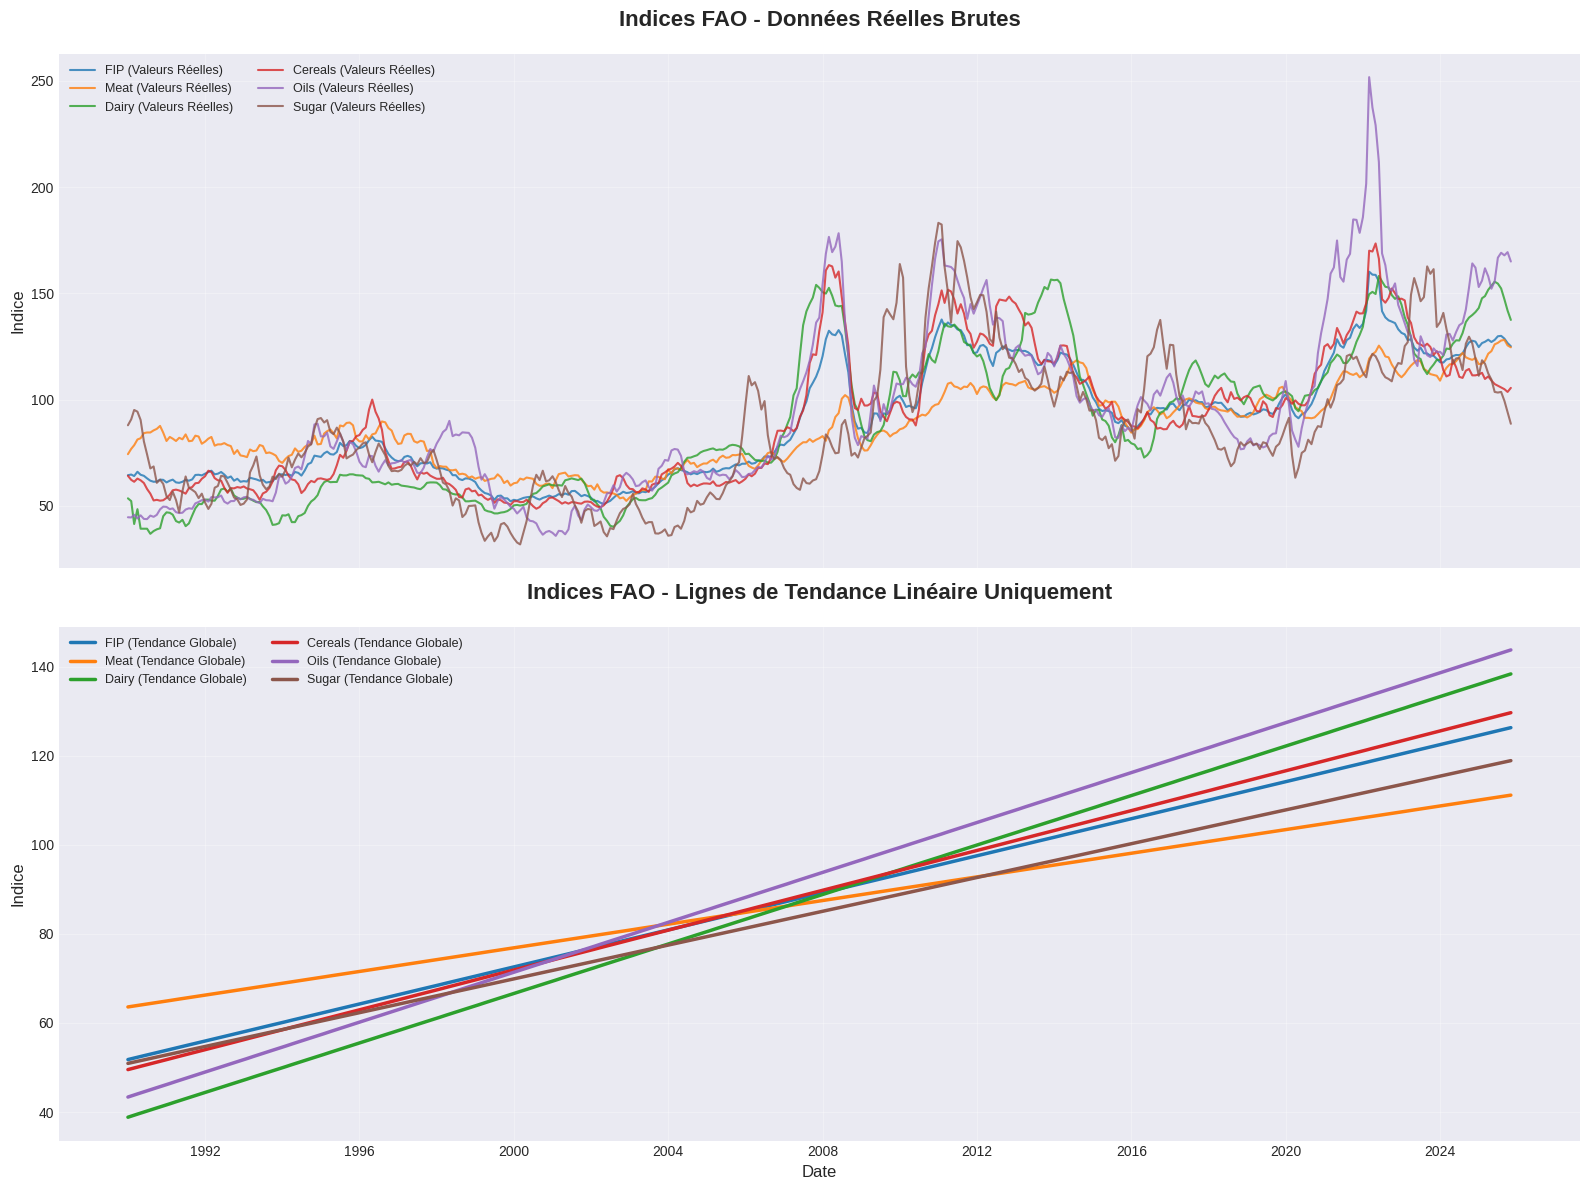

In [75]:
# Visualisation des tendances sur 2 graphiques séparés
fig, axes = plt.subplots(2, 1, figsize=(16, 12), sharex=True) # sharex=True pour synchroniser les axes X (Dates)

ax_reel = axes[0]
ax_tendance = axes[1]

colors_trend = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

for idx, col in enumerate(indices_cols):
    X = np.arange(len(dff1)).reshape(-1, 1)
    y = dff1[col].values
    
    model = LinearRegression()
    model.fit(X, y)
    y_trend = model.predict(X)
    
    # Graphe du haut: Données réelles
    ax_reel.plot(dff1['Date'], y, label=f'{col} (Valeurs Réelles)', linewidth=1.5, 
                 alpha=0.8, color=colors_trend[idx])
    
    # Graphe du bas: Lignes de tendance uniquement
    ax_tendance.plot(dff1['Date'], y_trend, label=f'{col} (Tendance Globale)', 
                     linewidth=2.5, alpha=1.0, color=colors_trend[idx])

# Configuration du graphique réel
ax_reel.set_title('Indices FAO - Données Réelles Brutes', fontsize=16, fontweight='bold', pad=20)
ax_reel.set_ylabel('Indice', fontsize=12)
ax_reel.legend(loc='upper left', fontsize=9, ncol=2)
ax_reel.grid(True, alpha=0.3)

# Configuration du graphique de tendance
ax_tendance.set_title('Indices FAO - Lignes de Tendance Linéaire Uniquement', fontsize=16, fontweight='bold', pad=20)
ax_tendance.set_xlabel('Date', fontsize=12)
ax_tendance.set_ylabel('Indice', fontsize=12)
ax_tendance.legend(loc='upper left', fontsize=9, ncol=2)
ax_tendance.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



## 6. ANALYSE DES VARIATIONS

[6] ANALYSE DES VARIATIONS
Objectif : Identifier les CHOCS mensuels

Ce qu'on calcule :


python
Variation (%) = ((Prix_mois_t - Prix_mois_t-1) / Prix_mois_t-1) × 100
```

**Exemple** :
```
Janvier 2008 : Cereals = 100
Février 2008 : Cereals = 115
Variation = +15%  <- CHOC !
```

**Graphique ** :
- Ligne autour de 0 = normal
- Pics > +10% = hausses anormales
- Creux < -10% = baisses anormales

**TOP 10 hausses/baisses** identifie :
- **Quand** : Dates des crises
- **Quoi** : Quel indice touché
- **Ampleur** : % de variation

**Pertinence** :
 **Système d'alerte** : Détecter crises en temps réel
 **Analyse causale** : Chercher causes (guerre, climat)
 **Préparation** : Anticiper effets sur prix locaux

---



[6] ANALYSE DES VARIATIONS

 Statistiques des variations mensuelles:
 Indice  Var_moyenne (%)  Var_médiane (%)  Var_std (%)  Var_max_hausse (%)  Var_max_baisse (%)
    FIP             0.41             0.42         2.56                7.80              -13.30
   Meat             0.29             0.37         2.34                7.52               -8.15
  Dairy             0.45             0.47         3.86               14.91              -11.20
Cereals             0.50             0.00         4.11               18.47              -16.28
   Oils             0.69             0.34         5.40               15.11              -23.53
  Sugar             0.63             0.58         7.26               21.75              -26.62

 TOP 10 - Plus fortes hausses mensuelles:
      Date  Indice  Valeur  Variation (%)
2009-08-01   Sugar   138.8      21.754386
2010-09-01   Sugar   138.7      21.029668
2010-08-01 Cereals   112.9      18.467996
2006-01-01   Sugar    97.5      18.038741
2009-05-01 

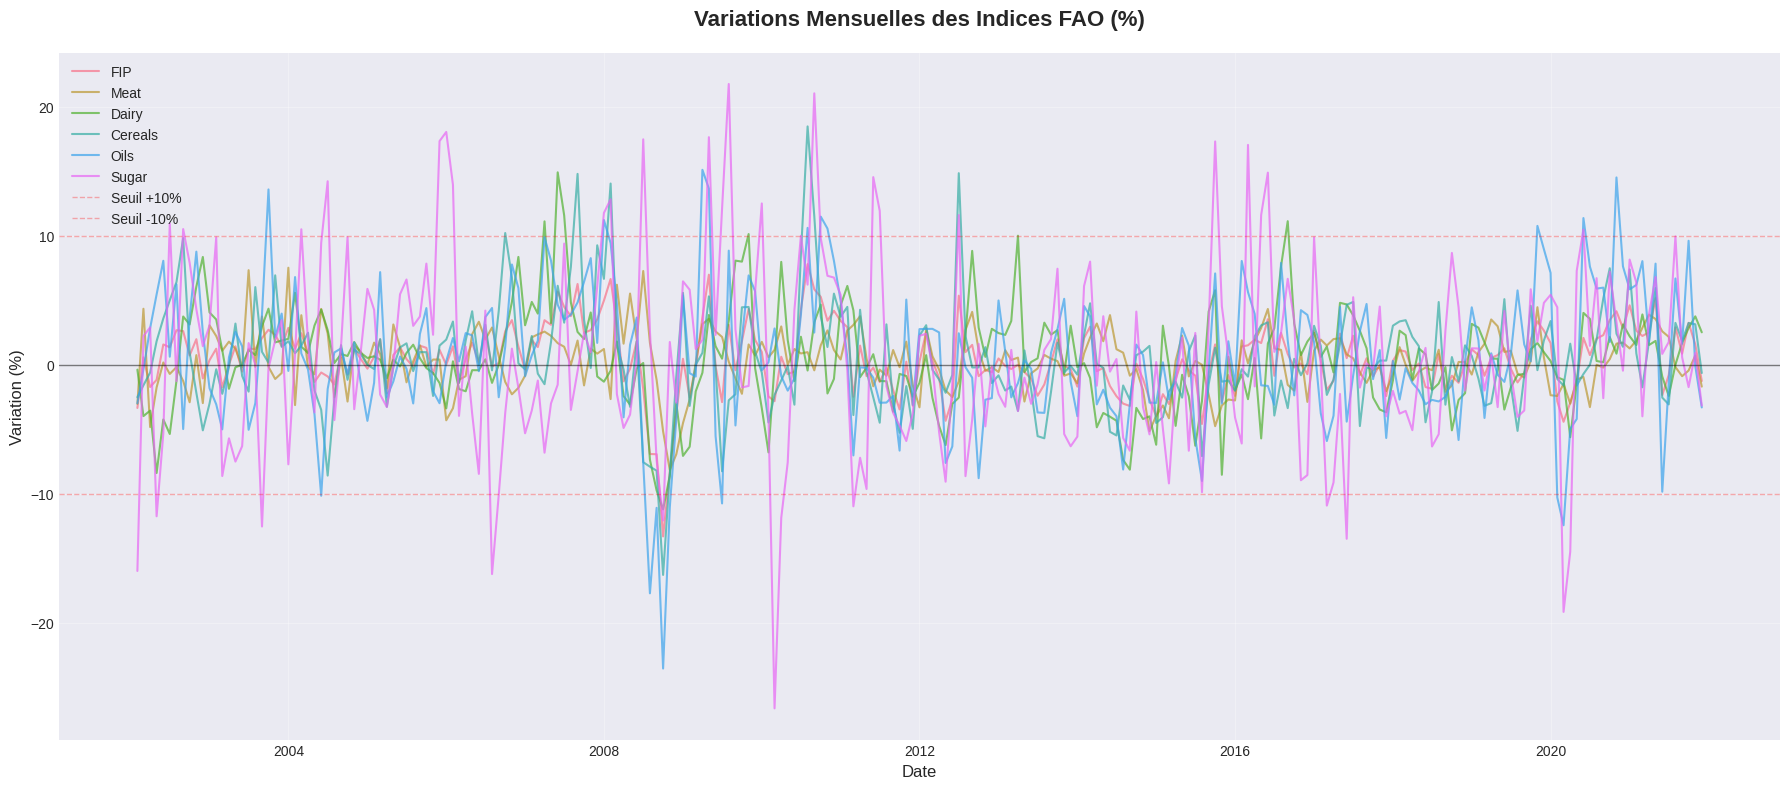

In [ ]:

# 6. ANALYSE DES VARIATIONS

print("\n\n[6] ANALYSE DES VARIATIONS")

# Calculer les variations mensuelles (%)
for col in indices_cols:
    dff1[f'{col}_change'] = dff1[col].pct_change() * 100

# Statistiques des variations
variation_stats = []
for col in indices_cols:
    change_col = f'{col}_change'
    variation_stats.append({
        'Indice': col,
        'Var_moyenne (%)': dff1[change_col].mean(),
        'Var_médiane (%)': dff1[change_col].median(),
        'Var_std (%)': dff1[change_col].std(),
        'Var_max_hausse (%)': dff1[change_col].max(),
        'Var_max_baisse (%)': dff1[change_col].min()
    })

variation_df = pd.DataFrame(variation_stats).round(2)

print("\n Statistiques des variations mensuelles:")
print(variation_df.to_string(index=False))

# Identifier les plus grands chocs
print("\n TOP 10 - Plus fortes hausses mensuelles:")
all_changes = []
for col in indices_cols:
    change_col = f'{col}_change'
    temp_df = dff1[['Date', col, change_col]].copy()
    temp_df['Indice'] = col
    temp_df = temp_df.rename(columns={col: 'Valeur', change_col: 'Variation (%)'})
    all_changes.append(temp_df)

all_changes_df = pd.concat(all_changes, ignore_index=True)
top_increases = all_changes_df.nlargest(10, 'Variation (%)')
print(top_increases[['Date', 'Indice', 'Valeur', 'Variation (%)']].to_string(index=False))

print("\n TOP 10 - Plus fortes baisses mensuelles:")
top_decreases = all_changes_df.nsmallest(10, 'Variation (%)')
print(top_decreases[['Date', 'Indice', 'Valeur', 'Variation (%)']].to_string(index=False))

# Visualisation des variations
fig, ax = plt.subplots(figsize=(18, 8))

for col in indices_cols:
    change_col = f'{col}_change'
    ax.plot(dff1['Date'], dff1[change_col], label=col, alpha=0.7, linewidth=1.5)

ax.axhline(0, color='black', linewidth=1, linestyle='-', alpha=0.5)
ax.axhline(10, color='red', linewidth=1, linestyle='--', alpha=0.3, label='Seuil +10%')
ax.axhline(-10, color='red', linewidth=1, linestyle='--', alpha=0.3, label='Seuil -10%')

ax.set_title('Variations Mensuelles des Indices FAO (%)', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Variation (%)', fontsize=12)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

[6] ANALYSE DES VARIATIONS
Objectif : Identifier les CHOCS mensuels

Ce qu'on calcule :


python
Variation (%) = ((Prix_mois_t - Prix_mois_t-1) / Prix_mois_t-1) × 100
```

**Exemple** :
```
Janvier 2008 : Cereals = 100
Février 2008 : Cereals = 115
Variation = +15%  <- CHOC !
```

**Graphique généré** :
- Ligne autour de 0 = normal
- Pics > +10% = hausses anormales
- Creux < -10% = baisses anormales

**TOP 10 hausses/baisses** identifie :
- **Quand** : Dates des crises
- **Quoi** : Quel indice touché
- **Ampleur** : % de variation

**Pertinence** :
 **Système d'alerte** : Détecter crises en temps réel
 **Analyse causale** : Chercher causes (guerre, climat)
 **Préparation** : Anticiper effets sur prix locaux


## 7. ANALYSE DE CORRÉLATION



[7] ANALYSE DE CORRÉLATION

 Matrice de corrélation:
           FIP   Meat  Dairy  Cereals   Oils  Sugar
FIP      1.000  0.876  0.898    0.969  0.931  0.753
Meat     0.876  1.000  0.766    0.784  0.693  0.668
Dairy    0.898  0.766  1.000    0.855  0.795  0.552
Cereals  0.969  0.784  0.855    1.000  0.917  0.664
Oils     0.931  0.693  0.795    0.917  1.000  0.692
Sugar    0.753  0.668  0.552    0.664  0.692  1.000

 Paires d'indices les plus corrélées:
Indice_1 Indice_2  Corrélation
     FIP  Cereals        0.969
     FIP     Oils        0.931
 Cereals     Oils        0.917
     FIP    Dairy        0.898
     FIP     Meat        0.876
   Dairy  Cereals        0.855
   Dairy     Oils        0.795
    Meat  Cereals        0.784
    Meat    Dairy        0.766
     FIP    Sugar        0.753


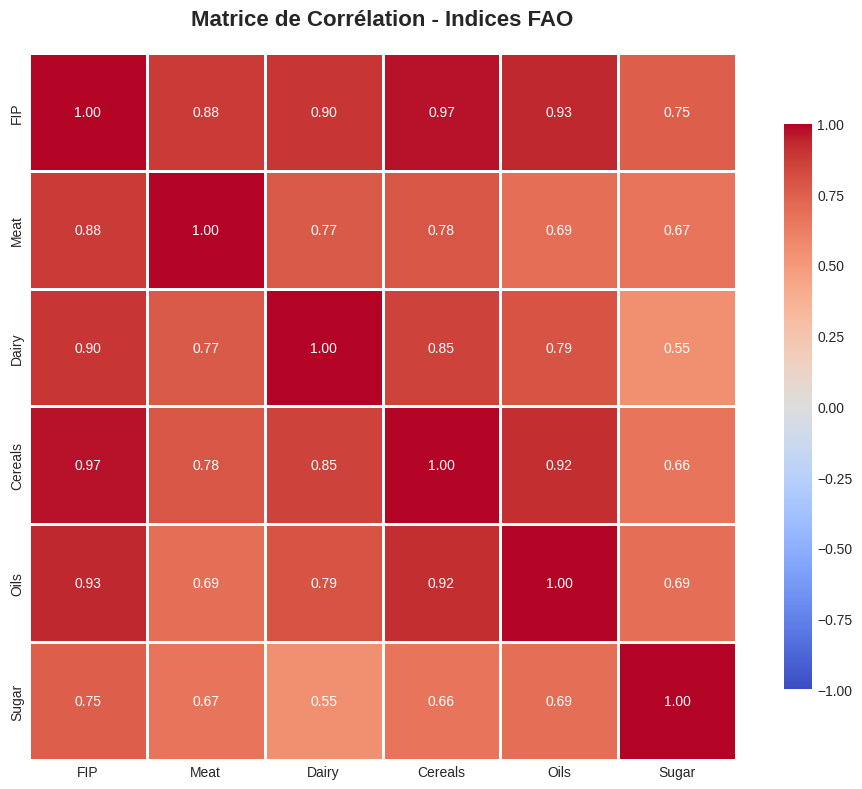

In [ ]:
# 7. ANALYSE DE CORRÉLATION


print("\n\n[7] ANALYSE DE CORRÉLATION")


# Matrice de corrélation
correlation_matrix = dff1[indices_cols].corr()

print("\n Matrice de corrélation:")
print(correlation_matrix.round(3).to_string())

# Identifier les paires les plus corrélées
corr_pairs = []
for i in range(len(indices_cols)):
    for j in range(i+1, len(indices_cols)):
        corr_pairs.append({
            'Indice_1': indices_cols[i],
            'Indice_2': indices_cols[j],
            'Corrélation': correlation_matrix.iloc[i, j]
        })

corr_pairs_df = pd.DataFrame(corr_pairs).sort_values('Corrélation', ascending=False)

print("\n Paires d'indices les plus corrélées:")
print(corr_pairs_df.head(10).round(3).to_string(index=False))

# Heatmap de corrélation
fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
           center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8},
           vmin=-1, vmax=1, ax=ax)

ax.set_title('Matrice de Corrélation - Indices FAO', fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()


## 8. ANALYSE DE SAISONNALITÉ



[8] ANALYSE DE SAISONNALITÉ

 Moyennes mensuelles:
         FIP   Meat   Dairy  Cereals    Oils  Sugar
Month                                              
1      94.14  85.85   98.01    98.20  100.76  93.39
2      94.96  86.00   98.84    99.40  102.12  94.44
3      94.86  86.98   99.57    98.76  102.08  89.72
4      95.02  87.92   99.50    98.81  102.53  86.20
5      95.58  88.98   99.02    99.39  103.56  85.32
6      95.71  89.90   99.62    99.14  102.04  86.40
7      95.84  90.78   99.93    98.24  100.26  91.22
8      96.04  91.16   99.85    98.59  100.26  91.07
9      96.32  91.06  100.78    99.30  100.03  91.35
10     96.58  90.11  101.61    99.98  100.59  93.85
11     97.21  90.08  101.61   100.39  103.90  93.50
12     97.32  89.02  102.06   101.09  105.03  93.50

 Intensité de la saisonnalité:
 Indice  Mois_Max  Mois_Min  Amplitude (%)
    FIP        12         1           3.32
   Meat         8         1           5.97
  Dairy        12         1           4.04
Cereals        

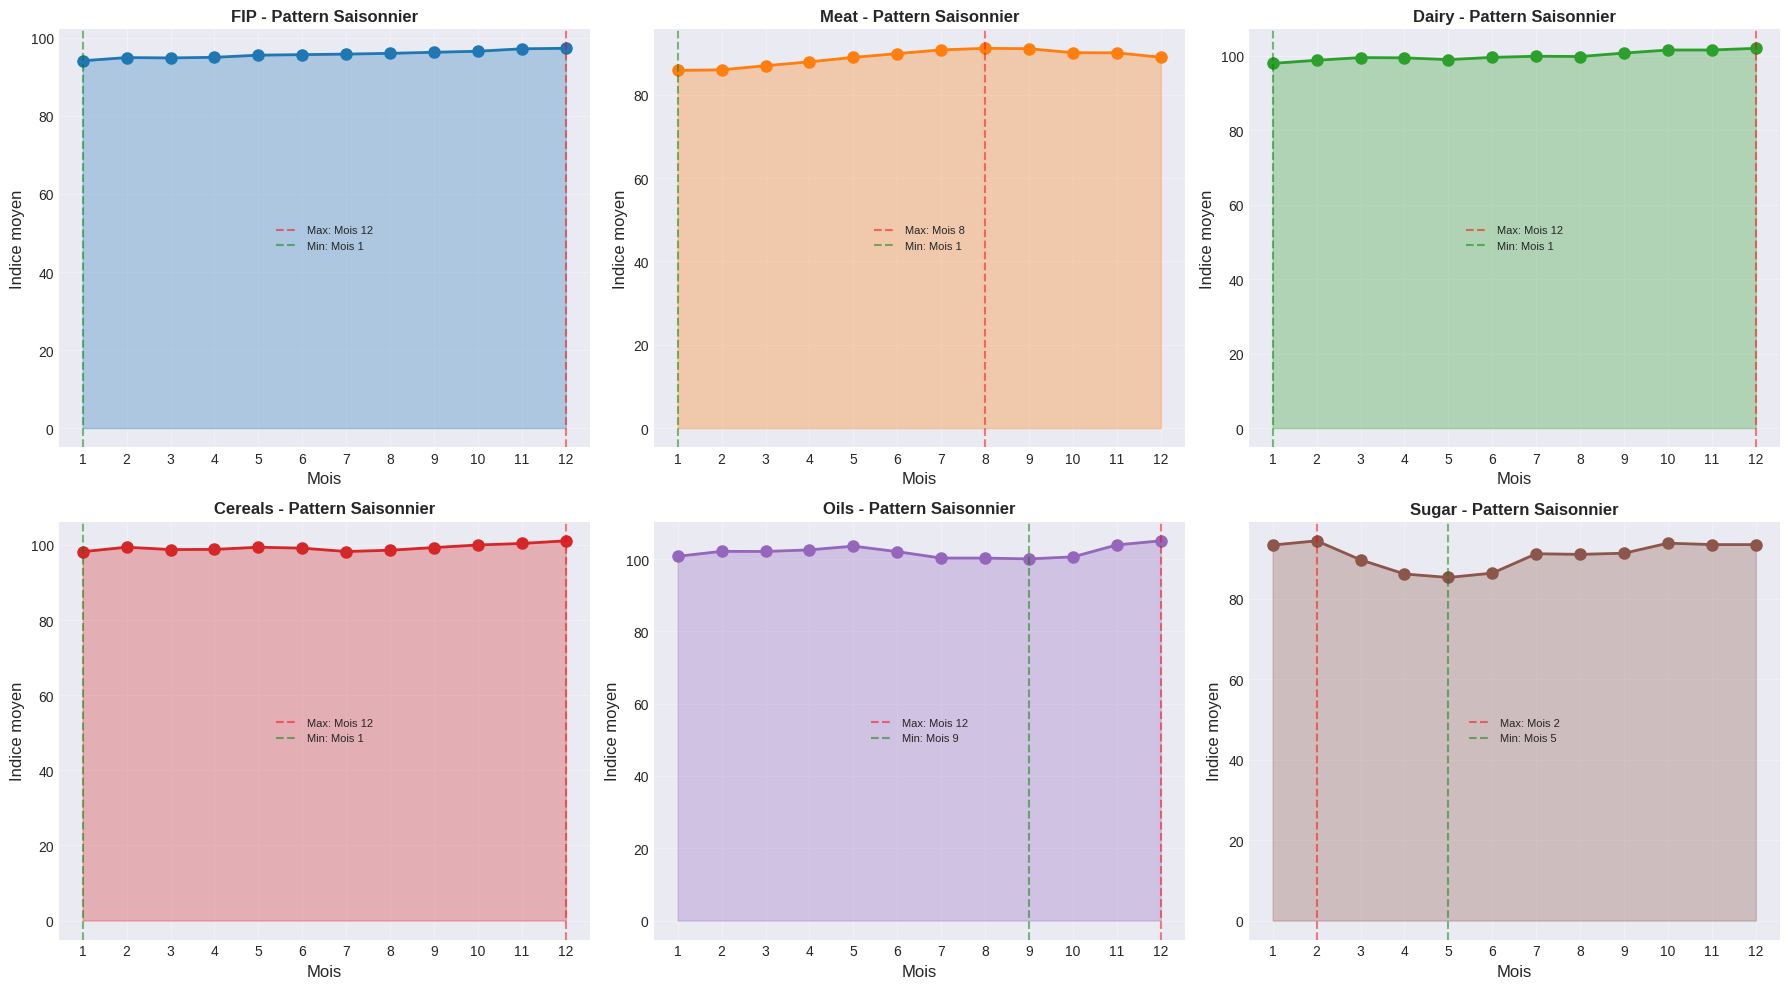

In [ ]:

# 8. ANALYSE DE SAISONNALITÉ


print("\n\n[8] ANALYSE DE SAISONNALITÉ")


# Pattern mensuel moyen
monthly_patterns = dff1.groupby('Month')[indices_cols].mean()

print("\n Moyennes mensuelles:")
print(monthly_patterns.round(2).to_string())

# Identifier mois haut/bas pour chaque indice
seasonality_summary = []
for col in indices_cols:
    max_month = monthly_patterns[col].idxmax()
    min_month = monthly_patterns[col].idxmin()
    amplitude = ((monthly_patterns[col].max() - monthly_patterns[col].min()) / 
                 monthly_patterns[col].mean()) * 100
    
    seasonality_summary.append({
        'Indice': col,
        'Mois_Max': max_month,
        'Mois_Min': min_month,
        'Amplitude (%)': amplitude
    })

seasonality_df = pd.DataFrame(seasonality_summary).round(2)

print("\n Intensité de la saisonnalité:")
print(seasonality_df.to_string(index=False))

# Visualisation patterns saisonniers
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, col in enumerate(indices_cols):
    ax = axes[idx]
    
    monthly_avg = dff1.groupby('Month')[col].mean()
    
    ax.plot(monthly_avg.index, monthly_avg.values, marker='o', 
           markersize=8, linewidth=2, color=colors[idx])
    ax.fill_between(monthly_avg.index, monthly_avg.values, alpha=0.3, color=colors[idx])
    
    # Marquer max et min
    max_month = monthly_avg.idxmax()
    min_month = monthly_avg.idxmin()
    
    ax.axvline(max_month, color='red', linestyle='--', alpha=0.5, label=f'Max: Mois {max_month}')
    ax.axvline(min_month, color='green', linestyle='--', alpha=0.5, label=f'Min: Mois {min_month}')
    
    ax.set_title(f'{col} - Pattern Saisonnier', fontsize=12, fontweight='bold')
    ax.set_xlabel('Mois')
    ax.set_ylabel('Indice moyen')
    ax.set_xticks(range(1, 13))
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. ANALYSE PAR PÉRIODE



[9] ANALYSE PAR PÉRIODE HISTORIQUE

 Analyse par période historique:
                    Période  FIP_moyen  FIP_max  Volatilité (%)
           Avant crise 2008      65.19    114.7           21.25
Crise alimentaire 2008-2011     112.05    137.7           16.32
                 Post-crise     103.94    125.7           12.22
            COVID & Ukraine     122.96    160.2           13.22


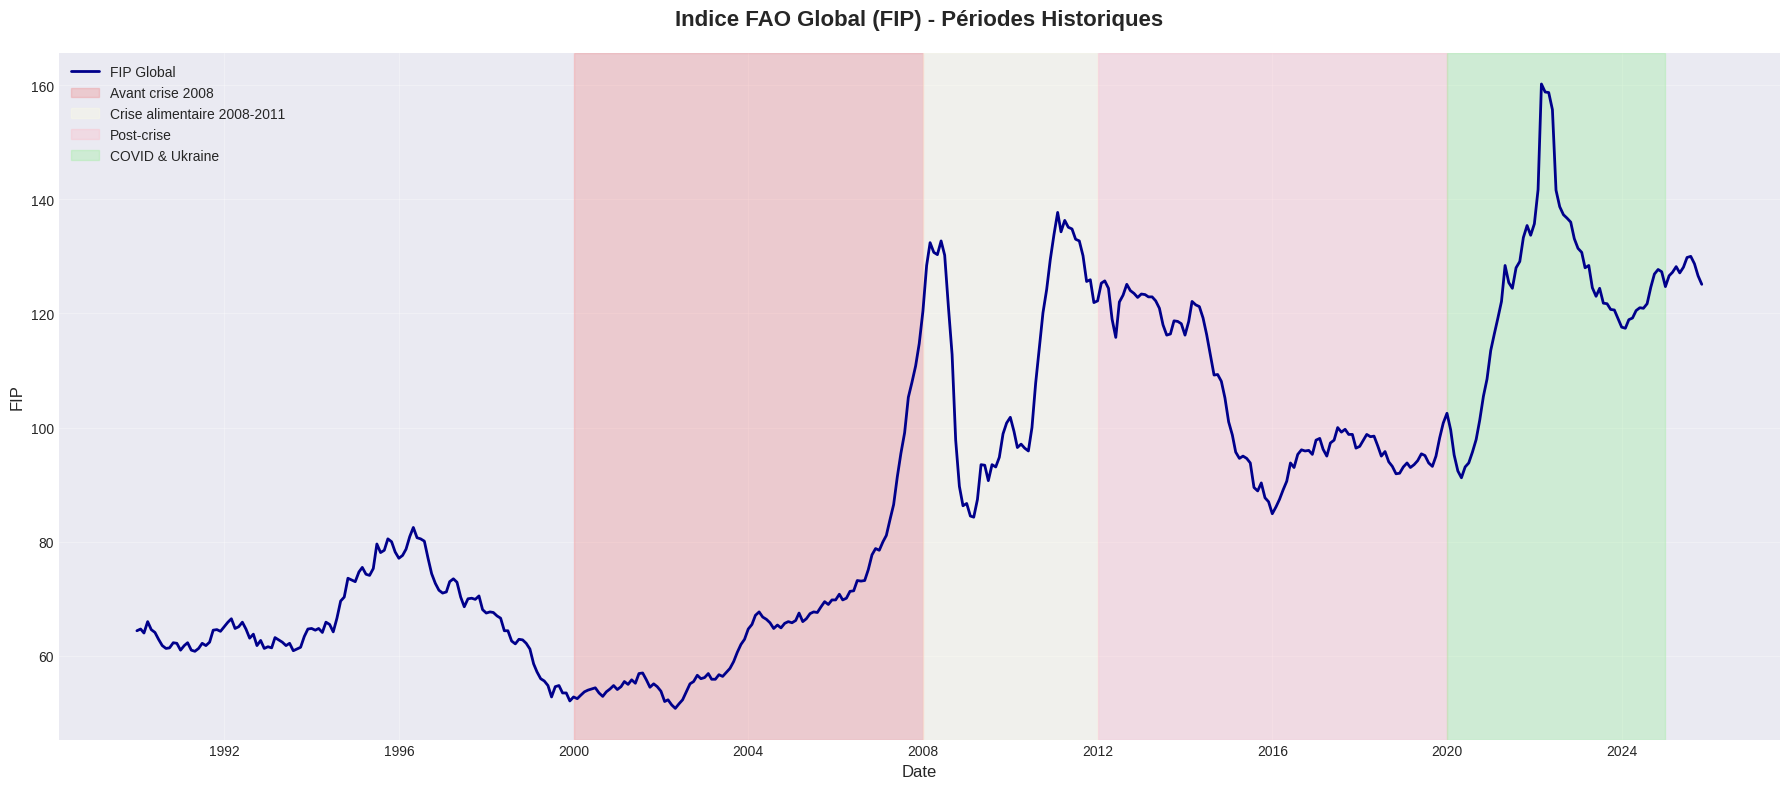

In [ ]:
# 9. ANALYSE PAR PÉRIODE (CRISES)


print("\n\n[9] ANALYSE PAR PÉRIODE HISTORIQUE")


# Définir des périodes clés
periods = {
    '2000-2007': ('2000-01-01', '2007-12-31', 'Avant crise 2008'),
    '2008-2011': ('2008-01-01', '2011-12-31', 'Crise alimentaire 2008-2011'),
    '2012-2019': ('2012-01-01', '2019-12-31', 'Post-crise'),
    '2020-2024': ('2020-01-01', '2024-12-31', 'COVID & Ukraine')
}

period_analysis = []
for period_name, (start, end, label) in periods.items():
    mask = (dff1['Date'] >= start) & (dff1['Date'] <= end)
    period_data = dff1[mask]
    
    if len(period_data) > 0:
        period_analysis.append({
            'Période': label,
            'FIP_moyen': period_data['FIP'].mean(),
            'FIP_max': period_data['FIP'].max(),
            'Volatilité (%)': (period_data['FIP'].std() / period_data['FIP'].mean() * 100)
        })

period_df = pd.DataFrame(period_analysis).round(2)

print("\n Analyse par période historique:")
print(period_df.to_string(index=False))

# Visualisation par période
fig, ax = plt.subplots(figsize=(18, 8))

ax.plot(dff1['Date'], dff1['FIP'], linewidth=2, color='darkblue', label='FIP Global')

# Marquer les périodes
period_colors = ['lightcoral', 'lightyellow', 'lightpink', 'lightgreen', 'lightblue']
for idx, (period_name, (start, end, label)) in enumerate(periods.items()):
    ax.axvspan(pd.to_datetime(start), pd.to_datetime(end), 
              alpha=0.3, color=period_colors[idx], label=label)

ax.set_title('Indice FAO Global (FIP) - Périodes Historiques', 
            fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('FIP', fontsize=12)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

